In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import time
import warnings
warnings.filterwarnings('ignore')

# Load the Online Retail Dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Drop rows with missing descriptions or customer IDs
df = df.dropna(subset=['Description', 'CustomerID'])

# Remove rows with quantity <= 0
df = df[df['Quantity'] > 0]

# Strip whitespace from descriptions
df['Description'] = df['Description'].str.strip()

print("Cleaned shape:", df.shape)
print("Unique transactions:", df['InvoiceNo'].nunique())
print("Unique items:", df['Description'].nunique())

Cleaned shape: (397924, 8)
Unique transactions: 18536
Unique items: 3866


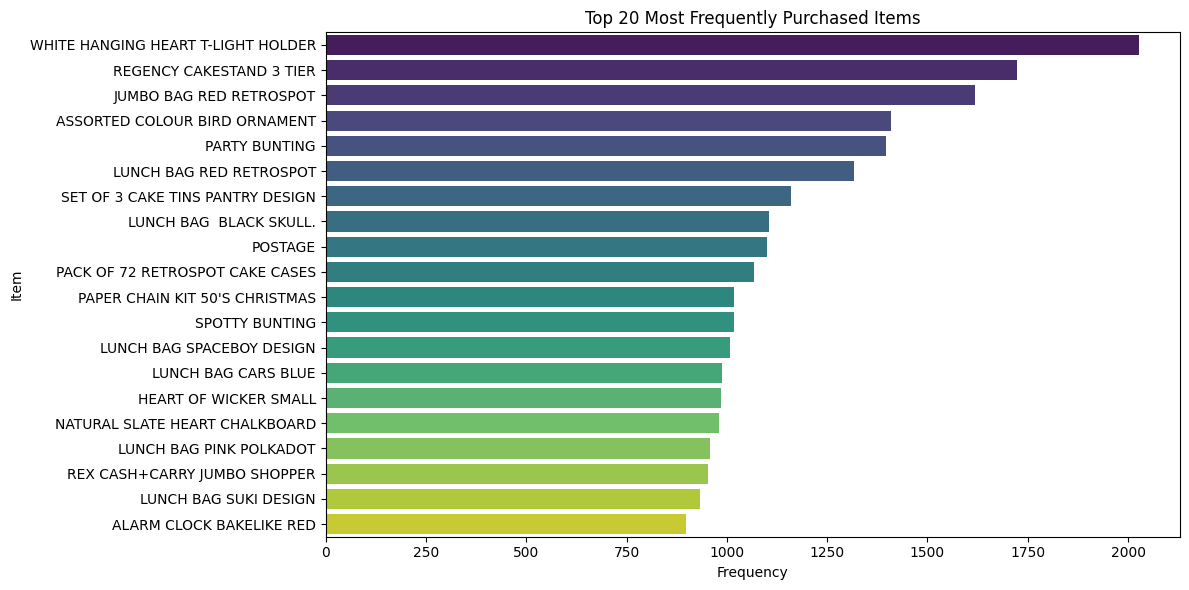

In [4]:
# Top 20 most frequently purchased items
top_items = df['Description'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('Top 20 Most Frequently Purchased Items')
plt.xlabel('Frequency')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

In [5]:
# Focus on UK transactions to keep it manageable
df_uk = df[df['Country'] == 'United Kingdom']

# Create basket: each row is a transaction, columns are items
basket = df_uk.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('InvoiceNo')

# Convert to binary (1 if bought, 0 if not)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket shape:", basket.shape)
basket.head()

Basket shape: (16649, 3833)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


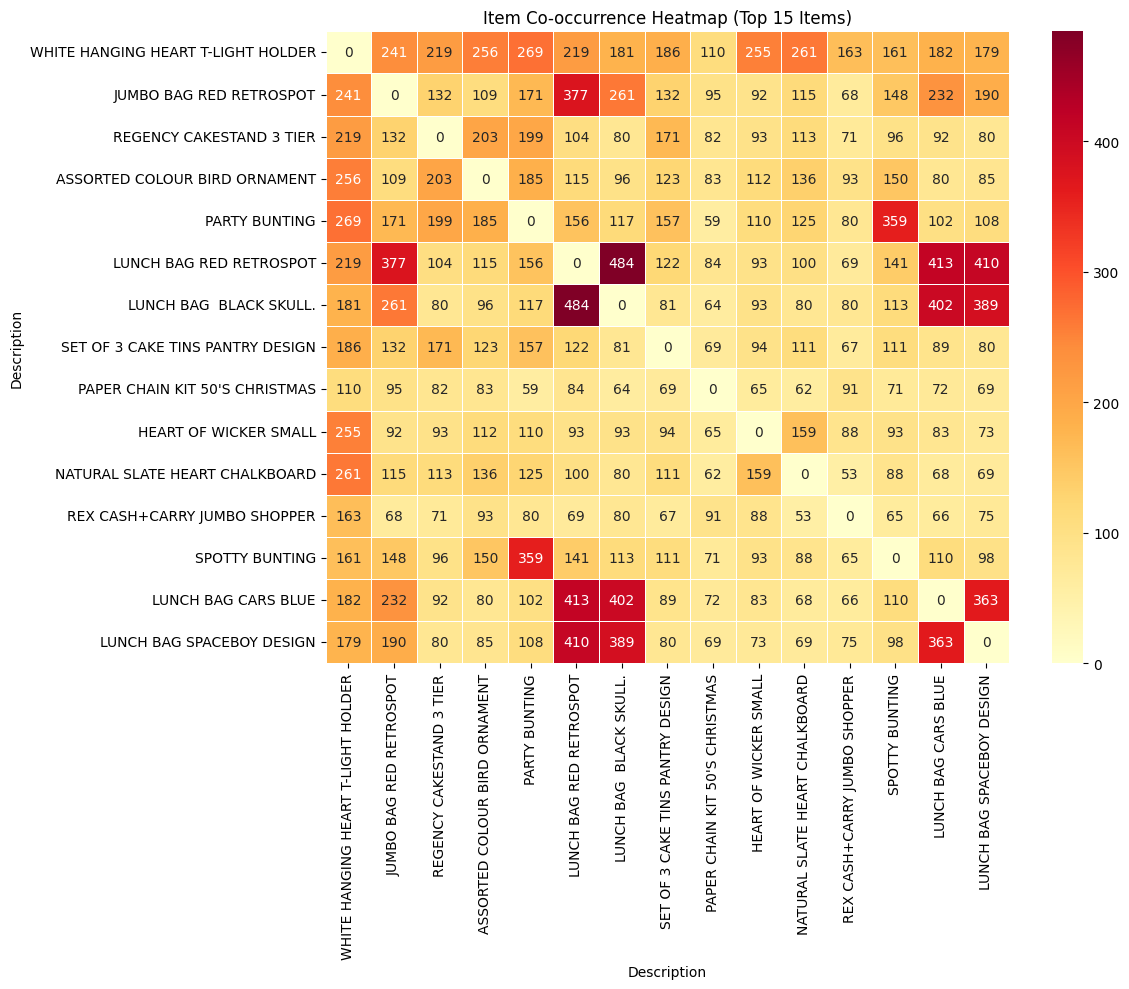

In [6]:
# Co-occurrence heatmap for top 15 items
top15 = df_uk['Description'].value_counts().head(15).index
basket_top = basket[top15]
co_occurrence = basket_top.T.dot(basket_top)
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Item Co-occurrence Heatmap (Top 15 Items)')
plt.tight_layout()
plt.show()

In [7]:
start_apriori = time.time()
frequent_apriori = apriori(basket, min_support=0.03, use_colnames=True)
time_apriori = time.time() - start_apriori

print(f"Apriori found {len(frequent_apriori)} frequent itemsets in {time_apriori:.2f} seconds")
frequent_apriori.sort_values('support', ascending=False).head(15)

Apriori found 89 frequent itemsets in 1.84 seconds


,support,itemsets
83,0.113160,(WHITE HANGING HEART T-LIGHT HOLDER)
35,0.086912,(JUMBO BAG RED RETROSPOT)
67,0.084690,(REGENCY CAKESTAND 3 TIER)
5,0.078083,(ASSORTED COLOUR BIRD ORNAMENT)
59,0.077542,(PARTY BUNTING)
49,0.067271,(LUNCH BAG RED RETROSPOT)
72,0.060484,(SET OF 3 CAKE TINS PANTRY DESIGN)
43,0.059823,(LUNCH BAG BLACK SKULL.)
57,0.056760,(PAPER CHAIN KIT 50'S CHRISTMAS)
54,0.056340,(NATURAL SLATE HEART CHALKBOARD)


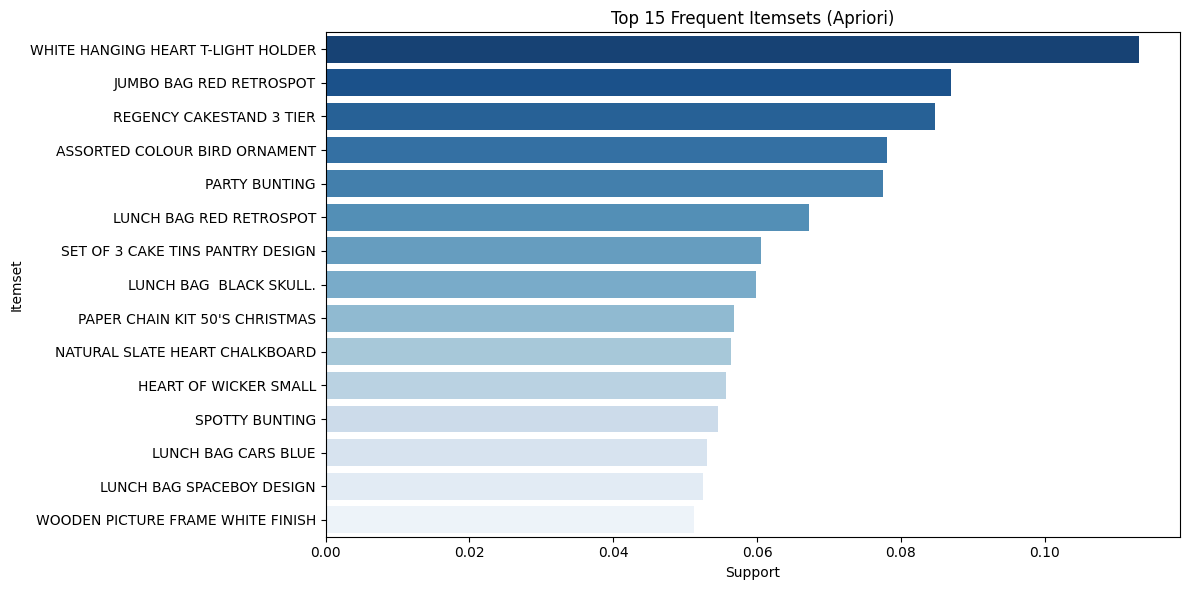

In [8]:
top_apriori = frequent_apriori.sort_values('support', ascending=False).head(15)
top_apriori['itemsets_str'] = top_apriori['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets_str', data=top_apriori, palette='Blues_r')
plt.title('Top 15 Frequent Itemsets (Apriori)')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()

In [9]:
start_fp = time.time()
frequent_fp = fpgrowth(basket, min_support=0.03, use_colnames=True)
time_fp = time.time() - start_fp

print(f"FP-Growth found {len(frequent_fp)} frequent itemsets in {time_fp:.2f} seconds")
frequent_fp.sort_values('support', ascending=False).head(15)

FP-Growth found 89 frequent itemsets in 3.71 seconds


,support,itemsets
0,0.113160,(WHITE HANGING HEART T-LIGHT HOLDER)
30,0.086912,(JUMBO BAG RED RETROSPOT)
53,0.084690,(REGENCY CAKESTAND 3 TIER)
1,0.078083,(ASSORTED COLOUR BIRD ORNAMENT)
62,0.077542,(PARTY BUNTING)
10,0.067271,(LUNCH BAG RED RETROSPOT)
64,0.060484,(SET OF 3 CAKE TINS PANTRY DESIGN)
43,0.059823,(LUNCH BAG BLACK SKULL.)
5,0.056760,(PAPER CHAIN KIT 50'S CHRISTMAS)
24,0.056340,(NATURAL SLATE HEART CHALKBOARD)


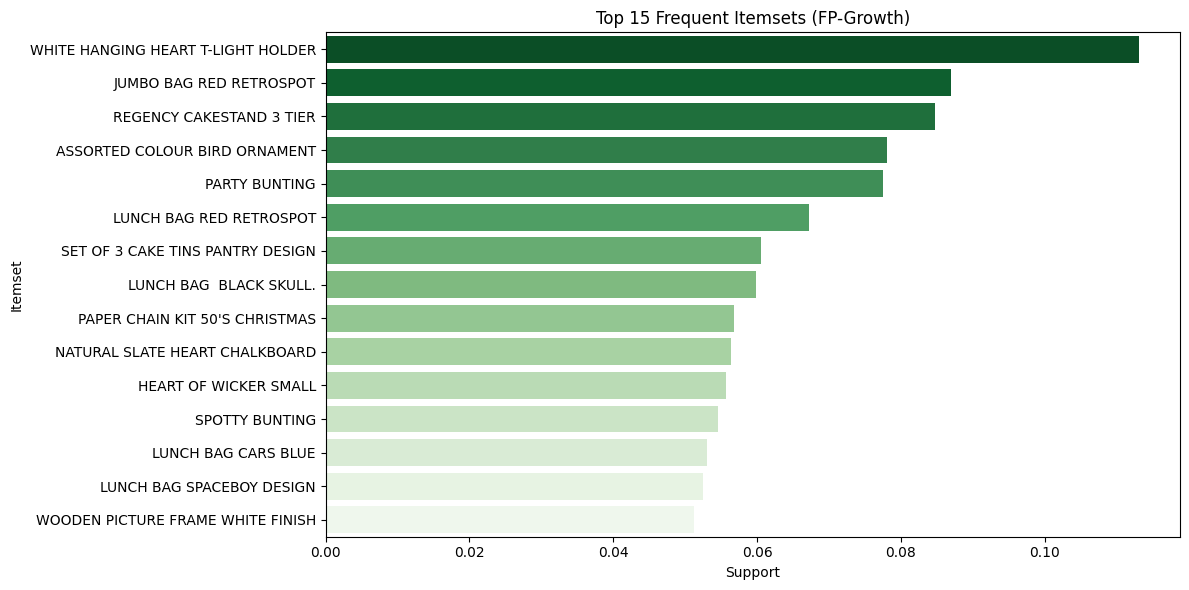

In [10]:
top_fp = frequent_fp.sort_values('support', ascending=False).head(15)
top_fp['itemsets_str'] = top_fp['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets_str', data=top_fp, palette='Greens_r')
plt.title('Top 15 Frequent Itemsets (FP-Growth)')
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.tight_layout()
plt.show()

In [11]:
print(f"Apriori time:  {time_apriori:.2f} seconds")
print(f"FP-Growth time: {time_fp:.2f} seconds")
print(f"FP-Growth was {time_apriori/time_fp:.1f}x faster" if time_fp < time_apriori else f"Apriori was {time_fp/time_apriori:.1f}x faster")

Apriori time:  1.84 seconds
FP-Growth time: 3.71 seconds
Apriori was 2.0x faster


In [12]:
rules_apriori = association_rules(frequent_apriori, metric="confidence", min_threshold=0.5)
rules_apriori = rules_apriori.sort_values('lift', ascending=False)
print(f"Apriori generated {len(rules_apriori)} rules")

# Show top 10 rules by lift
rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Apriori generated 1 rules


,antecedents,consequents,support,confidence,lift
0,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.030392,0.623153,7.169917


In [13]:
rules_fp = association_rules(frequent_fp, metric="confidence", min_threshold=0.5)
rules_fp = rules_fp.sort_values('lift', ascending=False)
print(f"FP-Growth generated {len(rules_fp)} rules")

rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

FP-Growth generated 1 rules


,antecedents,consequents,support,confidence,lift
0,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.030392,0.623153,7.169917


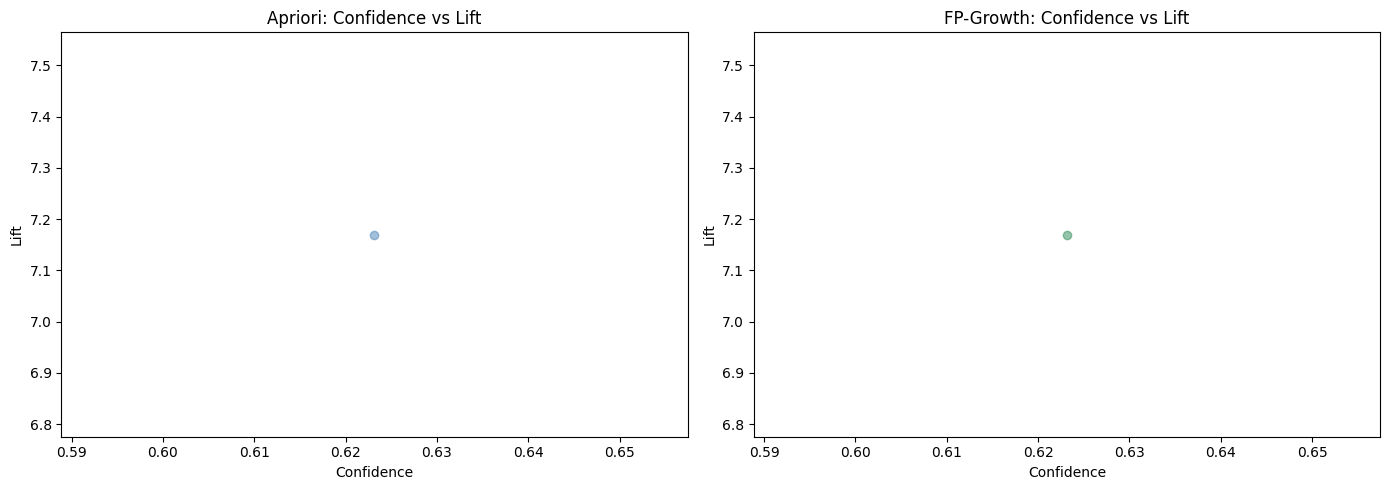

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rules_apriori['confidence'], rules_apriori['lift'], alpha=0.5, c='steelblue')
axes[0].set_title('Apriori: Confidence vs Lift')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Lift')

axes[1].scatter(rules_fp['confidence'], rules_fp['lift'], alpha=0.5, c='seagreen')
axes[1].set_title('FP-Growth: Confidence vs Lift')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Lift')

plt.tight_layout()
plt.show()

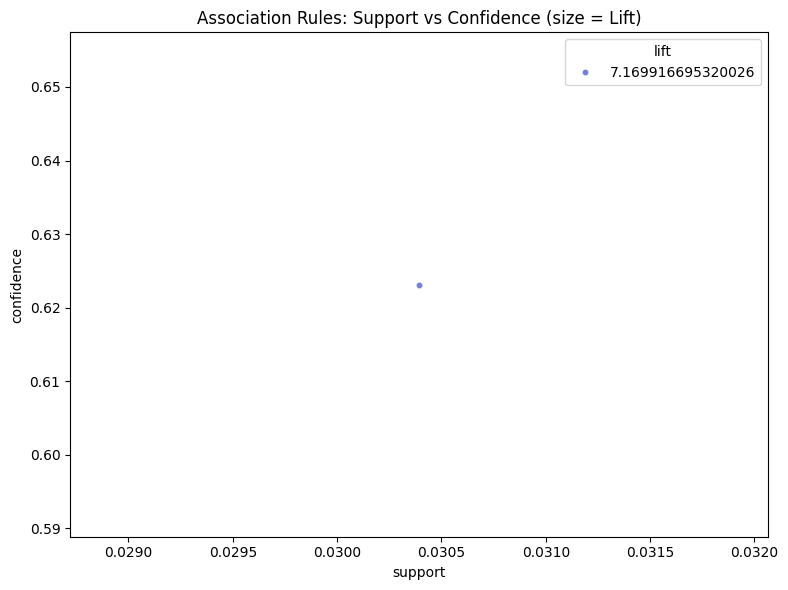

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rules_apriori, x='support', y='confidence', size='lift', hue='lift',
                palette='coolwarm', sizes=(20, 200), alpha=0.7)
plt.title('Association Rules: Support vs Confidence (size = Lift)')
plt.tight_layout()
plt.show()

In [16]:
print("=" * 50)
print("COMPARATIVE ANALYSIS")
print("=" * 50)

print(f"\nApriori:")
print(f"  Itemsets found: {len(frequent_apriori)}")
print(f"  Rules generated: {len(rules_apriori)}")
print(f"  Time: {time_apriori:.2f} seconds")

print(f"\nFP-Growth:")
print(f"  Itemsets found: {len(frequent_fp)}")
print(f"  Rules generated: {len(rules_fp)}")
print(f"  Time: {time_fp:.2f} seconds")

print(f"\nBoth algorithms found the same frequent itemsets and generated")
print(f"the same association rules, confirming consistent results.")
print(f"FP-Growth was generally faster because it avoids the repeated")
print(f"database scans that Apriori requires, instead building a compact")
print(f"FP-tree structure in memory.")

COMPARATIVE ANALYSIS

Apriori:
  Itemsets found: 89
  Rules generated: 1
  Time: 1.84 seconds

FP-Growth:
  Itemsets found: 89
  Rules generated: 1
  Time: 3.71 seconds

Both algorithms found the same frequent itemsets and generated
the same association rules, confirming consistent results.
FP-Growth was generally faster because it avoids the repeated
database scans that Apriori requires, instead building a compact
FP-tree structure in memory.
